# Step 2: Data Cleaning and Preprocessing

## Pre-requisites

Complete Step 1 in `data-collection.ipynb`

Import required packages

In [1107]:
import pandas as pd
import numpy as np
import seaborn as sns
import math

Read raw data downloaded from API endpoints and stored in `..\data` directory

In [1108]:
ebird_co_df = pd.read_csv("..\\data\\ebird_co.csv")
weather_stations_co_df = pd.read_csv("..\\data\\co_weather_stations.csv")
weather_co_df = pd.read_csv("..\\data\\co_weather.csv")
natural_disasters_co_df = pd.read_csv("..\\data\\co_natural_disasters.csv")
urban_pop_co_df = pd.read_csv("..\\data\\co_urban_pop.csv")

### Snapshots of raw data

In [1109]:
ebird_co_df

,speciesCode,comName,sciName,obsDt,queryDate,howMany,lat,lng,locId,locName,...,countryName,userDisplayName,obsId,checklistId,presenceNoted,hasComments,hasRichMedia,firstName,lastName,exoticCategory
0,batpig1,Band-tailed Pigeon,Patagioenas fasciata,2021-01-01 07:00:00,2021-01-01,1.0,39.560409,-107.293414,L1032655,No Name,...,United States,Thomas C. McConnell,OBS1052996918,CL22530,False,False,False,Thomas,C. McConnell,NaN
1,pinwar,Pine Warbler,Setophaga pinus,2021-01-01 07:00:00,2021-01-01,1.0,40.200837,-105.054303,L12877259,13810 WCR 1,...,United States,Bill Prather,OBS1040900074,CL24515,False,False,False,Bill,Prather,NaN
2,whwsco2,White-winged Scoter,Melanitta deglandi,2021-01-01 07:15:00,2021-01-01,1.0,40.298578,-105.168643,L825945,Dry Creek Reservoir,...,United States,Irene Fortune,OBS1041715728,CL23959,False,False,False,Irene,Fortune,NaN
3,brnthr,Brown Thrasher,Toxostoma rufum,2021-01-01 07:45:00,2021-01-01,1.0,40.032409,-105.293015,L9948193,3rd & Forest,...,United States,Thomas Heinrich (Green Birding),OBS2646282273,CL24481,False,False,False,Thomas,Heinrich (Green Birding),NaN
4,bongul,Bonaparte's Gull,Chroicocephalus philadelphia,2021-01-01 07:47:00,2021-01-01,2.0,38.273901,-104.736486,L6468992,Lake Pueblo SP--Sailboard area,...,United States,Rebecca Laroche,OBS1041315485,CL27541,False,False,False,Rebecca,Laroche,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354748,wiltur,Wild Turkey,Meleagris gallopavo,NaN,2025-09-29,17.0,39.027135,-104.597794,L973221,Jeannie Mitchell Home,...,United States,Anonymous eBirder,OBS3607393827,CL24267,False,False,False,Anonymous,eBirder,NaN
354749,wilpha,Wilson's Phalarope,Phalaropus tricolor,NaN,2023-09-18,10.0,40.115314,-105.120949,L131325,Little Gaynor Lake,...,United States,Josep Ramoneda,OBS1830756710,CL24481,False,False,False,Josep,Ramoneda,NaN
354750,wilsni1,Wilson's Snipe,Gallinago delicata,NaN,2022-01-25,1.0,39.605966,-105.951488,L867642,Keystone Ski Resort,...,United States,Kerry Nice,OBS2726831426,CL24842,False,False,False,Kerry,Nice,NaN
354751,yehbla,Yellow-headed Blackbird,Xanthocephalus xanthocephalus,NaN,2022-10-13,NaN,37.577899,-106.147922,L11866692,Monte Vista (town),...,United States,Roger Mattson,OBS1861153554,CL31558,True,False,False,Roger,Mattson,NaN


In [1110]:
weather_stations_co_df

,Unnamed: 0,elevation,mindate,maxdate,latitude,name,datacoverage,id,elevationUnit,longitude
0,0,1106.1,2017-08-01,2025-08-01,40.952800,"BIG SPRINGS 7.6 S, CO US",0.2989,GHCND:US10perk001,METERS,-102.053800
1,1,1554.8,2003-08-01,2023-09-01,39.861200,"THORNTON 2.3 SSE, CO US",0.8140,GHCND:US1COAD0022,METERS,-104.938156
2,2,1544.1,2005-05-01,2026-01-01,39.975200,"BRIGHTON 1.7 ESE, CO US",0.9636,GHCND:US1COAD0087,METERS,-104.790900
3,3,1609.0,2006-01-01,2026-01-01,39.922123,"THORNTON 2.1 N, CO US",0.9875,GHCND:US1COAD0100,METERS,-104.955296
4,4,1503.3,2009-06-01,2026-01-01,39.984390,"BRIGHTON 2.1 NNW, CO US",0.8498,GHCND:US1COAD0120,METERS,-104.813410
...,...,...,...,...,...,...,...,...,...,...
1758,1758,1940.8,1997-06-01,2026-01-01,40.044370,"MEEKER AIRPORT, CO US",0.9911,GHCND:USW00094050,METERS,-107.888360
1759,1759,1642.9,2003-08-01,2026-01-01,40.806600,"NUNN 7 NNE, CO US",0.9998,GHCND:USW00094074,METERS,-104.755200
1760,1760,2995.6,2003-10-01,2026-01-01,40.035400,"BOULDER 14 W, CO US",0.9961,GHCND:USW00094075,METERS,-105.540900
1761,1761,2258.9,2017-10-01,2026-01-01,40.053610,"KREMMLING MCELROY AIRFIELD, CO US",0.8996,GHCND:USW00094076,METERS,-106.368890


In [1111]:
weather_co_df

,Unnamed: 0,date,datatype,station,attributes,value
0,0,2021-01-01T00:00:00,TMAX,GHCND:USC00050109,",,,7",5.11
1,1,2021-01-01T00:00:00,TMAX,GHCND:USC00050128,",,,7",3.59
2,2,2021-01-01T00:00:00,TMAX,GHCND:USC00050214,",,,7",2.66
3,3,2021-01-01T00:00:00,TMAX,GHCND:USC00050263,",,,7",-2.37
4,4,2021-01-01T00:00:00,TMAX,GHCND:USC00050306,",,,7",7.64
...,...,...,...,...,...,...
107961,107961,2024-12-01T00:00:00,RHMX,GHCND:USW00093037,",,,W",73.00
107962,107962,2024-12-01T00:00:00,RHMX,GHCND:USW00093058,",,,W",83.00
107963,107963,2024-12-01T00:00:00,RHMX,GHCND:USW00093069,",,,W",85.00
107964,107964,2024-12-01T00:00:00,RHMX,GHCND:USW00093073,",,,W",84.00


In [1112]:
natural_disasters_co_df

,Unnamed: 0,femaDeclarationString,disasterNumber,state,declarationType,declarationDate,fyDeclared,incidentType,declarationTitle,ihProgramDeclared,...,placeCode,designatedArea,declarationRequestNumber,lastIAFilingDate,incidentId,region,designatedIncidentTypes,lastRefresh,hash,id
0,0,FM-5423-CO,5423,CO,FM,2021-12-30T00:00:00.000Z,2022,Fire,MARSHALL FIRE,False,...,99013,Boulder (County),21132,NaN,2021123101,8,NaN,2024-08-27T18:22:14.800Z,3f0e9054a42676d0d7f75b6279f972d18c4b39bb,b8cb17aa-bb52-45b5-80ed-3dcd3e2c7486
1,1,DR-4634-CO,4634,CO,DR,2021-12-31T00:00:00.000Z,2022,Fire,WILDFIRES AND STRAIGHT-LINE WINDS,True,...,99013,Boulder (County),22001,2022-03-02T00:00:00.000Z,2022010101,8,NaN,2024-08-27T18:22:14.800Z,3f2ce967d16d48c7a12b74a1c31859243f1ed5fa,b61bd47d-de3a-4a86-887e-94595817d28f
2,2,DR-4581-CO,4581,CO,DR,2021-01-15T00:00:00.000Z,2021,Fire,WILDFIRES,False,...,99049,Grand (County),20328,NaN,2020122301,8,NaN,2024-08-27T18:22:14.800Z,3f9db442ca63530ecfcf6603b3e4a08401ecabd5,10e97111-a9ad-4270-b86f-8ec936e0aa8c
3,3,DR-4581-CO,4581,CO,DR,2021-01-15T00:00:00.000Z,2021,Fire,WILDFIRES,False,...,99069,Larimer (County),20328,NaN,2020122301,8,NaN,2024-08-27T18:22:14.800Z,ec0a151b3cdbe45d5eb94d018f23ec417af9533e,98e30bb6-82ac-4838-8f4e-c547fdb9006c
4,4,FM-5604-CO,5604,CO,FM,2025-08-06T00:00:00.000Z,2025,Fire,ELK FIRE,False,...,99103,Rio Blanco (County),25109,NaN,2025080701,8,R,2025-08-08T19:42:11.470Z,889b9529a11f0a115d0682b03ce22da55239cfba,b4d54825-9061-437e-89dd-6db50192d3a4
5,5,FM-5603-CO,5603,CO,FM,2025-08-06T00:00:00.000Z,2025,Fire,LEE FIRE,False,...,99103,Rio Blanco (County),25108,NaN,2025080702,8,R,2025-08-08T19:42:11.470Z,73656c8219ea708cd77945c00a931f269eae775f,28b8935e-4883-443a-877e-8fcb6441b389
6,6,FM-5606-CO,5606,CO,FM,2025-08-11T00:00:00.000Z,2025,Fire,OAK FIRE,False,...,99007,Archuleta (County),25111,NaN,2025081101,8,R,2025-08-13T13:42:02.273Z,c4308ef3ad120b43c5e354d74b016b03ba0cbf80,3fd39a94-6af3-455e-9ca6-e827c28e853f
7,7,FM-5526-CO,5526,CO,FM,2024-08-01T00:00:00.000Z,2024,Fire,QUARRY FIRE,False,...,99059,Jefferson (County),24106,NaN,2024080102,8,R,2025-01-08T20:01:25.309Z,c6eff9d2ab33acbeeab7424deae19f7de7e3288d,0d51ec82-33ec-4cf2-91ed-f689507dd98c
8,8,FM-5525-CO,5525,CO,FM,2024-07-31T00:00:00.000Z,2024,Fire,STONE MOUNTAIN FIRE,False,...,99013,Boulder (County),24105,NaN,2024073103,8,R,2025-01-08T20:01:25.309Z,692612f9b487af921c69600ef70b07fd4f95d815,212d16ff-852c-4208-9db5-ef2705e13e37
9,9,FM-5525-CO,5525,CO,FM,2024-07-31T00:00:00.000Z,2024,Fire,STONE MOUNTAIN FIRE,False,...,99069,Larimer (County),24105,NaN,2024073103,8,R,2025-01-08T20:01:25.309Z,b1ce0b36270cc6978ae4fad36df17912f5c1906a,94386e02-7bcc-4451-8999-b0af0728bd39


In [1113]:
urban_pop_co_df

,Unnamed: 0,County Name,Total Pop,Urban Pop,State FIPS,County FIPS,Urban Percentage
0,0,"Adams County, Colorado",519572,498576,8,1,95.96
1,1,"Alamosa County, Colorado",16376,10965,8,3,66.96
2,2,"Arapahoe County, Colorado",655070,641552,8,5,97.94
3,3,"Archuleta County, Colorado",13359,5632,8,7,42.16
4,4,"Baca County, Colorado",3506,0,8,9,0.00
...,...,...,...,...,...,...,...
59,59,"Jackson County, Colorado",1379,0,8,57,0.00
60,60,"Jefferson County, Colorado",582910,541241,8,59,92.85
61,61,"Washington County, Colorado",4817,0,8,121,0.00
62,62,"Weld County, Colorado",328981,263140,8,123,79.99


## Data Cleaning

#### Remove any trailing and leading whitespaces from all columns with string values.

In [1114]:
def remove_trailing_leading_spaces (df):
    df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

dfs = [ebird_co_df, weather_co_df, weather_stations_co_df, natural_disasters_co_df, urban_pop_co_df]

for df in dfs:
    remove_trailing_leading_spaces(df)

## Data Preprocessing

### Bird sightings data

#### Select and rename columns for analysis

In [1115]:
# Select and rename the following columns:
# {"speciesCode": "species_code",
# "comName": "common_name",
# "obsDt": "date",
# "howMany": "count",
# "lat": "latitude",
# "lng": "longitude"
# }
ebird_co_df = ebird_co_df[["speciesCode", "comName", "obsDt", "howMany", "lat", "lng"]]
ebird_co_df = ebird_co_df.rename(columns = {
    "speciesCode": "species_code",
    "comName": "common_name",
    "obsDt": "date",
    "howMany": "count",
    "lat": "latitude",
    "lng": "longitude"
    }
    )

#### eBird data assessment

In [1116]:
# Check for missing values
ebird_co_df.isnull().sum()

species_code       0
common_name        0
date             286
count           5068
latitude           0
longitude          0
dtype: int64

In [1117]:
# Check for duplicate rows
ebird_co_df[ebird_co_df.duplicated()]

,species_code,common_name,date,count,latitude,longitude
354469,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354471,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354473,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354474,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354475,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354476,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354477,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354481,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354482,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905
354483,brnowl,American Barn Owl,NaN,1.0,40.657507,-104.958905


In [1118]:
# See data types of columns
ebird_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 354753 entries, 0 to 354752
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   species_code  354753 non-null  str    
 1   common_name   354753 non-null  str    
 2   date          354467 non-null  str    
 3   count         349685 non-null  float64
 4   latitude      354753 non-null  float64
 5   longitude     354753 non-null  float64
dtypes: float64(3), str(3)
memory usage: 16.2 MB


In [1119]:
# Get summary statistics
ebird_co_df.describe(include='all')

,species_code,common_name,date,count,latitude,longitude
count,354753,354753,354467,349685.000000,354753.000000,354753.000000
unique,567,567,170215,NaN,NaN,NaN
top,pygnut,Pygmy Nuthatch,2022-05-01 19:38:00,NaN,NaN,NaN
freq,1794,1794,54,NaN,NaN,NaN
mean,NaN,NaN,NaN,7.062322,39.373802,-105.467221
std,NaN,NaN,NaN,164.480295,0.956256,1.408123
min,NaN,NaN,NaN,1.000000,36.993038,-109.057416
25%,NaN,NaN,NaN,1.000000,38.745482,-105.833909
50%,NaN,NaN,NaN,1.000000,39.628014,-105.103519
75%,NaN,NaN,NaN,3.000000,40.046409,-104.853859


#### Address missing values in `date` and `count`

From the above data summary, there are 286 observations with `NaN` in `date` and 5068 observations with `NaN` in `count`. Since these make up a very small portion of the total number of 354753 observations, we have decided to drop these records.

In [1120]:
ebird_co_df.dropna(axis = 0, inplace = True)

#### Map bird sighting lat-long coordinates to counties

We do this so that bird sightings can be analyzed along with external factors like weather, natural disasters, and urban population at a county level.

In [1121]:
# Map bird sighting lat-long coordinates to CO counties by finding the county whose centroid is closest to the coordinates in terms of Euclidean distance.

# Function to find nearest county to a set of lat-long co-ordinates by calculating Euclidean distances to county centroids
def get_nearest_county(lat, lon):
    nearest_county = None
    min_dist = float("inf")

    # List of CO county centroid coorindates
    co_county_centroids = {
        "Adams": (39.8743, -104.3318),
        "Alamosa": (37.5741, -105.7866),
        "Arapahoe": (39.6524, -104.6747),
        "Archuleta": (37.1900, -107.0500),
        "Baca": (37.3200, -102.5600),
        "Bent": (37.9550, -103.0720),
        "Boulder": (40.0567, -105.3291),
        "Broomfield": (39.9497, -105.0705),
        "Chaffee": (38.7398, -106.1846),
        "Cheyenne": (38.8280, -102.6030),
        "Clear Creek": (39.7210, -105.6581),
        "Conejos": (37.2010, -106.1920),
        "Costilla": (37.2780, -105.4280),
        "Crowley": (38.3270, -103.7850),
        "Custer": (38.1090, -105.3670),
        "Delta": (38.8610, -107.8630),
        "Denver": (39.7048, -104.9555),
        "Dolores": (37.7476, -108.5304),
        "Douglas": (39.3484, -105.0939),
        "Eagle": (39.6280, -106.6950),
        "El Paso": (38.9268, -104.5696),
        "Elbert": (39.2870, -104.1360),
        "Fremont": (38.4730, -105.4400),
        "Garfield": (39.5990, -107.9040),
        "Gilpin": (39.8594, -105.5166),
        "Grand": (40.1565, -106.0356),
        "Gunnison": (38.6670, -107.0320),
        "Hinsdale": (37.8200, -107.2800),
        "Huerfano": (37.6847, -104.9606),
        "Jackson": (40.6664, -106.3428),
        "Jefferson": (39.5864, -105.2505),
        "Kiowa": (38.4326, -102.7402),
        "Kit Carson": (39.3055, -102.6030),
        "La Plata": (37.2866, -107.8433),
        "Lake": (39.2025, -106.3448),
        "Larimer": (40.6664, -105.4612),
        "Las Animas": (37.3158, -104.0387),
        "Lincoln": (38.9881, -103.5140),
        "Logan": (40.7247, -103.1101),
        "Mesa": (39.0183, -108.4664),
        "Mineral": (37.6689, -106.9241),
        "Moffat": (40.6184, -108.2074),
        "Montezuma": (37.3386, -108.5966),
        "Montrose": (38.4022, -108.2693),
        "Morgan": (40.2626, -103.8097),
        "Otero": (37.9026, -103.7165),
        "Ouray": (38.1555, -107.7693),
        "Park": (39.1194, -105.7172),
        "Phillips": (40.5940, -102.3576),
        "Pitkin": (39.2171, -106.9166),
        "Prowers": (37.9552, -102.3934),
        "Pueblo": (38.1735, -104.5127),
        "Rio Blanco": (39.9798, -108.2171),
        "Rio Grande": (37.5825, -106.3832),
        "Routt": (40.4851, -106.9913),
        "Saguache": (38.0805, -106.2815),
        "San Juan": (37.7640, -107.6762),
        "San Miguel": (38.0038, -108.4057),
        "Sedgwick": (40.8759, -102.3518),
        "Summit": (39.6342, -106.1164),
        "Teller": (38.8824, -105.1617),
        "Washington": (39.9710, -103.2012),
        "Weld": (40.5548, -104.3925),
        "Yuma": (40.0029, -102.4243)
        }

    for county, (olat, olon) in co_county_centroids.items():
        # Simple Euclidean distance (sufficient for "nearest" classification in small areas)
        dist = math.sqrt((lat - olat)**2 + (lon - olon)**2)

        if dist < min_dist:
            min_dist = dist
            nearest_county = county

    return nearest_county

# Create new column to store counties where birds were sighted for each observation
ebird_co_df["county"] = [get_nearest_county(lat, lon) for lat, lon in zip(ebird_co_df["latitude"], ebird_co_df["longitude"])]
ebird_co_df.drop(columns = ["latitude", "longitude"], inplace = True)

#### Change date and time of observations into a monthly format

We do this to align the eBird data with weather data which is on a monthly basis.

In [1122]:
ebird_co_df["date"] = pd.to_datetime(ebird_co_df["date"])
ebird_co_df["date"] = ebird_co_df["date"].dt.to_period("M")

#### Snapshot of data after cleaning and preprocessing

In [1123]:
ebird_co_df

,species_code,common_name,date,count,county
0,batpig1,Band-tailed Pigeon,2021-01,1.0,Pitkin
1,pinwar,Pine Warbler,2021-01,1.0,Broomfield
2,whwsco2,White-winged Scoter,2021-01,1.0,Boulder
3,brnthr,Brown Thrasher,2021-01,1.0,Boulder
4,bongul,Bonaparte's Gull,2021-01,2.0,Pueblo
...,...,...,...,...,...
354462,sancra,Sandhill Crane,2025-12,1.0,Weld
354463,scaqua,Scaled Quail,2025-12,3.0,Prowers
354464,bnhcow,Brown-headed Cowbird,2025-12,1.0,Broomfield
354465,whtspa,White-throated Sparrow,2025-12,1.0,Larimer


### Weather station data

#### Select and rename columns for analysis

In [1124]:
# Select and rename the following columns:
# {"id": "station_id",
# "latitude": "latitude",
# "longitutde": "longitude",
# }
weather_stations_co_df = weather_stations_co_df[["id", "latitude", "longitude"]]
weather_stations_co_df = weather_stations_co_df.rename(columns = {
    "id": "station_id"
})

#### Weather station data assessment

In [1125]:
# Check for missing values
weather_stations_co_df.isnull().sum()

station_id    0
latitude      0
longitude     0
dtype: int64

In [1126]:
# Check for duplicates
weather_stations_co_df[weather_stations_co_df.duplicated()]

,station_id,latitude,longitude


In [1127]:
# Get data types of columns
weather_stations_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1763 entries, 0 to 1762
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   station_id  1763 non-null   str    
 1   latitude    1763 non-null   float64
 2   longitude   1763 non-null   float64
dtypes: float64(2), str(1)
memory usage: 41.4 KB


In [1128]:
# Get summary statistics
weather_stations_co_df.describe(include = "all")

,station_id,latitude,longitude
count,1763,1763.000000,1763.000000
unique,1763,NaN,NaN
top,GHCND:US10perk001,NaN,NaN
freq,1,NaN,NaN
mean,NaN,39.333831,-105.576508
std,NaN,1.026447,1.415850
min,NaN,37.010290,-109.053090
25%,NaN,38.734315,-106.370650
50%,NaN,39.581300,-105.144780
75%,NaN,40.138463,-104.864845


#### Map weather station lat-long coordinates to counties

We do this so that weather data can be analyzed along with bird sightings and other external factors like natural disasters and urban population at a county level.

In [1129]:
# Create new column for counties where birds were sighted for each observation
weather_stations_co_df["county"] = [get_nearest_county(lat, lon) for lat, lon in zip(weather_stations_co_df["latitude"], weather_stations_co_df["longitude"])]
weather_stations_co_df.drop(columns = ["latitude", "longitude"], inplace = True)

#### Snapshot of data after cleaning and preprocessing

In [1130]:
weather_stations_co_df

,station_id,county
0,GHCND:US10perk001,Sedgwick
1,GHCND:US1COAD0022,Denver
2,GHCND:US1COAD0087,Broomfield
3,GHCND:US1COAD0100,Broomfield
4,GHCND:US1COAD0120,Broomfield
...,...,...
1758,GHCND:USW00094050,Rio Blanco
1759,GHCND:USW00094074,Weld
1760,GHCND:USW00094075,Gilpin
1761,GHCND:USW00094076,Grand


### Weather data

#### Select and rename columns for analysis

In [1131]:
# Select and rename the following columns:
# {"date": "date",
# "datatype": "data_type",
# "station": "station_id",
# "value": "value"
# }

weather_co_df = weather_co_df[["date", "datatype", "station", "value"]]
weather_co_df = weather_co_df.rename(columns = {
    "datatype": "data_type",
    "station": "station_id"
}
)

#### Weather data assessment

In [1132]:
# Check for missing values
weather_co_df.isnull().sum()

date          0
data_type     0
station_id    0
value         0
dtype: int64

In [1133]:
# Check for duplicate rows
weather_co_df[weather_co_df.duplicated()]

,date,data_type,station_id,value


In [1134]:
# See data types of columns
weather_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 107966 entries, 0 to 107965
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        107966 non-null  str    
 1   data_type   107966 non-null  str    
 2   station_id  107966 non-null  str    
 3   value       107966 non-null  float64
dtypes: float64(1), str(3)
memory usage: 3.3 MB


In [1135]:
# Get summary statistics
weather_co_df.describe(include = "all")

,date,data_type,station_id,value
count,107966,107966,107966,107966.000000
unique,60,6,1760,NaN
top,2023-08-01T00:00:00,PRCP,GHCND:USW00023061,NaN
freq,1894,62265,335,NaN
mean,NaN,NaN,NaN,24.799602
std,NaN,NaN,NaN,31.415943
min,NaN,NaN,NaN,-28.120000
25%,NaN,NaN,NaN,4.500000
50%,NaN,NaN,NaN,16.000000
75%,NaN,NaN,NaN,34.200000


#### Change the date to a monthly format

We do this since the weather data is on a monthly basis.

In [1136]:
weather_co_df["date"] = pd.to_datetime(weather_co_df["date"])
weather_co_df["date"] = weather_co_df["date"].dt.to_period("M")

#### Pivot DataFrame to wide format so that each type of weather data has its own column 

We do this the weather data returned from NCEI's API service is in a long format where each record describes just one weather data type observed at a given station in a given month.

In [1137]:
# Pivot weather DataFrame so that each weather data type ["TMAX", "TMIN", "PRCP", "AWND", "RHMN", "RHMX"] has its own column
weather_co_df = weather_co_df.pivot(
    index = ["date", "station_id"],
    columns = "data_type",
    values = "value"
).reset_index()

# Rename new columns for weather data types
# {"AWND": "monthly_average_wind_speed",
# "PRCP": "total_monthly_precipitation",
# "RHMN": "monthly_average_of_minimum_relative_humidity",
# "RHMX": "monthly_average_of_maximum_relative_humidity",
# "TMAX": "monthly_maximum_temperature",
# "TMIN": "monthly_minimum_temperature",
# }
weather_co_df = weather_co_df.rename(columns = {
    "AWND": "monthly_avg_wind_speed",
    "PRCP": "total_monthly_precipitation",
    "RHMN": "monthly_avg_of_min_relative_humidity",
    "RHMX": "monthly_avg_of_max_relative_humidity",
    "TMAX": "monthly_max_temp",
    "TMIN": "monthly_min_temp"
})

#### Join weather DataFrame with weather station DataFrame

We do this to match weather data to the counties where the observations were made. We are interested only in weather observations that can be associated with a weather station, so an inner join is performed.

In [1138]:
# Join weather data with weather stations data
weather_co_df = pd.merge(
    left = weather_co_df,
    right = weather_stations_co_df, 
    how = "inner", 
    on = "station_id"
    )

weather_co_df.drop(columns=["station_id"], inplace = True)

#### Aggregate monthly weather data at county level

In [1139]:
weather_co_df = weather_co_df.groupby(["date", "county"], as_index = False).mean()

#### Snapshot of data after cleaning and preprocessing

In [1140]:
weather_co_df

,date,county,monthly_avg_wind_speed,total_monthly_precipitation,monthly_avg_of_min_relative_humidity,monthly_avg_of_max_relative_humidity,monthly_max_temp,monthly_min_temp
0,2021-01,Alamosa,2.2,8.100000,41.0,89.0,2.476667,-14.746667
1,2021-01,Arapahoe,4.1,7.077419,33.0,73.0,7.710000,-5.960000
2,2021-01,Archuleta,NaN,41.736364,NaN,NaN,4.435000,-13.655000
3,2021-01,Baca,5.2,10.371429,NaN,NaN,9.377500,-5.680000
4,2021-01,Bent,NaN,10.120000,NaN,NaN,8.193333,-7.816667
...,...,...,...,...,...,...,...,...
3832,2025-12,Summit,NaN,41.600000,NaN,NaN,1.898182,-9.010909
3833,2025-12,Teller,NaN,15.392857,NaN,NaN,7.647500,-6.217500
3834,2025-12,Washington,4.4,2.316667,NaN,NaN,12.410000,-4.573333
3835,2025-12,Weld,2.8,4.936667,NaN,NaN,11.615000,-6.143333


In [1141]:
weather_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3837 entries, 0 to 3836
Data columns (total 8 columns):
 #   Column                                Non-Null Count  Dtype    
---  ------                                --------------  -----    
 0   date                                  3837 non-null   period[M]
 1   county                                3837 non-null   str      
 2   monthly_avg_wind_speed                1617 non-null   float64  
 3   total_monthly_precipitation           3836 non-null   float64  
 4   monthly_avg_of_min_relative_humidity  668 non-null    float64  
 5   monthly_avg_of_max_relative_humidity  668 non-null    float64  
 6   monthly_max_temp                      3714 non-null   float64  
 7   monthly_min_temp                      3714 non-null   float64  
dtypes: float64(6), period[M](1), str(1)
memory usage: 239.9 KB


Data for `monthly_avg_wind_speed`, `monthly_avg_of_min_relative_humidity`, and `monthy_avg_of_max_relative_humidity` are sparse. It appears that many weather stations don't collect such data.

### Urban population data

#### Select and rename columns for analysis

In [1142]:
# Select and rename the following columns:
# {"County Name": "county",
# "urban_population_level": "urban_population_level"
# }
urban_pop_co_df = urban_pop_co_df[["County Name", "Urban Percentage"]]
urban_pop_co_df = urban_pop_co_df.rename(columns = {
    "County Name": "county",
    "Urban Percentage": "urban_percentage"
})

We are interested in the Urban Percentage value for each Colorado county.
The latest available data is from the Decennial Census 2020.
Assuming that the total population and urban population of each county grows at the same rate from 2020 until now, the Urban Percentage values would remain the same.

#### Urban population data assessment

In [1143]:
# Check for missing values
urban_pop_co_df.isnull().sum()

county              0
urban_percentage    0
dtype: int64

In [1144]:
# Check for duplicate rows
urban_pop_co_df[urban_pop_co_df.duplicated()]

,county,urban_percentage


In [1145]:
# See data types of columns
urban_pop_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   county            64 non-null     str    
 1   urban_percentage  64 non-null     float64
dtypes: float64(1), str(1)
memory usage: 1.1 KB


In [1146]:
# Get summary statistics
urban_pop_co_df.describe(include = "all")

,county,urban_percentage
count,64,64.000000
unique,64,NaN
top,"Adams County, Colorado",NaN
freq,1,NaN
mean,NaN,37.754219
std,NaN,37.338454
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,37.135000
75%,NaN,67.250000


#### Discretization of Urban Percentage by binning

We believe that binning the Urban Percentage values is suitable for two reasons. First, it eliminates the uncertainty around Urban Percentage values that arise from the assumption that they remain unchanged since 2020. Second, there is a large number rural counties whose Urban Percentage value is zero, which means that in the distribution, there is a concentration of data points at zero. Grouping the non-zero values into bins would lead to a smoother distribution of Urban Percentage values.

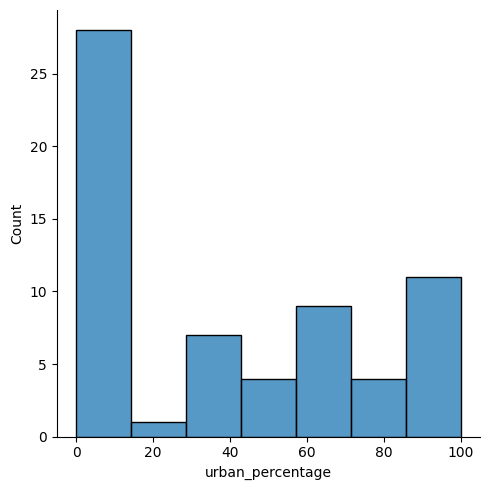

In [1147]:
# Plot of distribution of Urban Percentage values
sns.displot(urban_pop_co_df, x = "urban_percentage")

In [1148]:
# Group Urban Percentage values into the following bins:
# {1: 0 <= x < 20,
# 2: 20 <= x < 40,
# 3: 40 <= x < 60,
# 4: 60 <= x < 80,
# 5: 80 <= x < 100}
urban_pop_co_df["urban_population_level"] = pd.cut(urban_pop_co_df["urban_percentage"], bins = 5, labels = ["1", "2", "3", "4", "5"])
urban_pop_co_df.drop(columns = ["urban_percentage"], inplace = True)

#### Format county name to keep it consistent with other data

In [1149]:
# Parse the county name from "county" to keep it in the same format as the eBird and weather data
urban_pop_co_df["county"] = urban_pop_co_df["county"].str.extract(r"(^.+)\sCounty.*")

#### Snapshot of data after cleaning and preprocessing

In [1150]:
urban_pop_co_df

,county,urban_population_level
0,Adams,5
1,Alamosa,4
2,Arapahoe,5
3,Archuleta,3
4,Baca,1
...,...,...
59,Jackson,1
60,Jefferson,5
61,Washington,1
62,Weld,4


### Natural disaster data

#### Select and rename columns for analysis

In [1151]:
# Select and rename the following columns
# { "declarationDate": "declaration_date",
# "incidentType": "incident_type",
# "incidentBeginDate": "incident_begin_date",
# "incidentEndDate": "incident_end_date",
# "designatedArea": "county"
# }

natural_disasters_co_df = natural_disasters_co_df[["declarationDate", "incidentType", "incidentBeginDate", "incidentEndDate", "designatedArea"]]
natural_disasters_co_df = natural_disasters_co_df.rename(columns = {
    "declarationDate": "declaration_date",
    "incidentType": "incident_type",
    "incidentBeginDate": "incident_begin_date",
    "incidentEndDate": "incident_end_date",
    "designatedArea": "county"
})

#### Natural disaster data assessment

In [1152]:
# Check for missing values
natural_disasters_co_df.isnull().sum()

declaration_date       0
incident_type          0
incident_begin_date    0
incident_end_date      3
county                 0
dtype: int64

In [1153]:
# Check for duplicate rows
natural_disasters_co_df[natural_disasters_co_df.duplicated()]

,declaration_date,incident_type,incident_begin_date,incident_end_date,county
5,2025-08-06T00:00:00.000Z,Fire,2025-08-02T00:00:00.000Z,NaN,Rio Blanco (County)


In [1154]:
# See data types of columns
natural_disasters_co_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   declaration_date     25 non-null     str  
 1   incident_type        25 non-null     str  
 2   incident_begin_date  25 non-null     str  
 3   incident_end_date    22 non-null     str  
 4   county               25 non-null     str  
dtypes: str(5)
memory usage: 1.1 KB


In [1155]:
# Get summary statistics
natural_disasters_co_df.describe(include = "all")

,declaration_date,incident_type,incident_begin_date,incident_end_date,county
count,25,25,25,22,25
unique,8,2,8,6,19
top,2023-08-25T00:00:00.000Z,Flood,2023-06-08T00:00:00.000Z,2023-06-23T00:00:00.000Z,Boulder (County)
freq,14,14,14,14,3


There are two types of natural disasters in Colorado from 2021 to 2025: Fires and floods.

In [1156]:
natural_disasters_co_df["incident_type"].unique()

<StringArray>
['Fire', 'Flood']
Length: 2, dtype: str

#### Format county name to keep it consistent with other data

In [1157]:
# Parse the county name from "county" to keep it in the same format as the eBird and weather data
natural_disasters_co_df["county"] = natural_disasters_co_df["county"].str.extract(r"(^.+)\s\(County\).*")

#### Convert datetime columns from string to datetime format

In [1158]:
natural_disasters_co_df["declaration_date"] = pd.to_datetime(natural_disasters_co_df["declaration_date"])
natural_disasters_co_df["incident_begin_date"] = pd.to_datetime(natural_disasters_co_df["incident_begin_date"])
natural_disasters_co_df["incident_end_date"] = pd.to_datetime(natural_disasters_co_df["incident_end_date"])

#### Address missing values in `incident_end_date`

In [1159]:
natural_disasters_co_df[natural_disasters_co_df["incident_end_date"].isna()]

,declaration_date,incident_type,incident_begin_date,incident_end_date,county
4,2025-08-06 00:00:00+00:00,Fire,2025-08-02 00:00:00+00:00,NaT,Rio Blanco
5,2025-08-06 00:00:00+00:00,Fire,2025-08-02 00:00:00+00:00,NaT,Rio Blanco
6,2025-08-11 00:00:00+00:00,Fire,2025-08-10 00:00:00+00:00,NaT,Archuleta


We impute the missing values of `incident_end_date` by calculating the mean duration of fires in Colorado from 2021 to 2025 and add it to `incident_begin_date`.

In [1160]:
fire_durations = natural_disasters_co_df[natural_disasters_co_df["incident_end_date"].notna()]["incident_end_date"] - natural_disasters_co_df[natural_disasters_co_df["incident_end_date"].notna()]["incident_begin_date"]
natural_disasters_co_df["incident_end_date"] = natural_disasters_co_df["incident_end_date"].fillna(natural_disasters_co_df["incident_begin_date"] + fire_durations.mean())

#### Change dates to a monthly format

We do this to align with eBird and weather data which is on a monthly basis

In [1161]:
def convert_datetime_to_month(df_column):
    natural_disasters_co_df[df_column] = pd.to_datetime(natural_disasters_co_df[df_column])
    natural_disasters_co_df[df_column] = natural_disasters_co_df[df_column].dt.to_period("M")

df_columns = ["declaration_date", "incident_begin_date", "incident_end_date"]

for df_column in df_columns:
    convert_datetime_to_month(df_column)

C:\Users\kenny\AppData\Local\Temp\ipykernel_45024\126389664.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  natural_disasters_co_df[df_column] = natural_disasters_co_df[df_column].dt.to_period("M")
C:\Users\kenny\AppData\Local\Temp\ipykernel_45024\126389664.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  natural_disasters_co_df[df_column] = natural_disasters_co_df[df_column].dt.to_period("M")
C:\Users\kenny\AppData\Local\Temp\ipykernel_45024\126389664.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  natural_disasters_co_df[df_column] = natural_disasters_co_df[df_column].dt.to_period("M")


#### Show natural disaster occurrence as binary variables

To analyze the impact of fires and floods, we create a new DataFrame that shows the presence of a flood or fire in each county in each month, using binary variables to represent the presence of a fire or a flood.

In [1162]:
dates = pd.date_range(start = "2021-01-01", end = "2025-12-31", freq = "MS").to_period("M")
counties = urban_pop_co_df["county"]

# Create DataFrame from cartesian join of dates and counties
disaster_tracker_df = pd.MultiIndex.from_product([dates, counties], names = ["date", "county"]).to_frame(index = False)

# Create binary variables with initial values of 0
disaster_tracker_df["is_fire"] = 0
disaster_tracker_df["is_flood"] = 0

for _, row in natural_disasters_co_df.iterrows():
    # Select column of disaster_tracker_df to update
    col = "is_fire" if row["incident_type"] == "Fire" else "is_flood"
    
    # Create boolean mask for rows in disaster_tracker_df
    # The mask assigns 1 (True) to a row if it meets all 3 conditions
    # which indicates that a disaster occurred in that county in that month
    mask = (disaster_tracker_df["county"] == row["county"]) & \
           (disaster_tracker_df["date"] >= row["incident_begin_date"]) & \
           (disaster_tracker_df["date"] <= row["incident_end_date"])
    
    # Update 0 to 1
    disaster_tracker_df.loc[mask, col] = 1

#### Snapshot of data after cleaning and preprocessing

In [1163]:
disaster_tracker_df

,date,county,is_fire,is_flood
0,2021-01,Adams,0,0
1,2021-01,Alamosa,0,0
2,2021-01,Arapahoe,0,0
3,2021-01,Archuleta,0,0
4,2021-01,Baca,0,0
...,...,...,...,...
3835,2025-12,Jackson,0,0
3836,2025-12,Jefferson,0,0
3837,2025-12,Washington,0,0
3838,2025-12,Weld,0,0


### Data integration

First, join weather, urban population, and natural disaster data into a dataset of external factors.
To keep observations for each combination of `date` and `county`, an outer join is performed.

In [1164]:
externals_co_df = pd.merge(
    left = weather_co_df,
    right = urban_pop_co_df,
    how = "outer",
    on = "county",
    indicator = True
)

externals_co_df["_merge"].value_counts()

_merge
both          3837
left_only        0
right_only       0
Name: count, dtype: int64

In [1165]:
externals_co_df.drop(columns = ["_merge"], inplace = True)

In [1166]:
externals_co_df = pd.merge(
    left = externals_co_df,
    right = disaster_tracker_df,
    how = "left",
    on = ["date", "county"],
    indicator = True
)

externals_co_df["_merge"].value_counts()

_merge
both          3837
left_only        0
right_only       0
Name: count, dtype: int64

In [1167]:
externals_co_df.drop(columns = ["_merge"], inplace = True)

Join bird sightings data with external factors data.

In [1168]:
birdsong_df = pd.merge(
    left = ebird_co_df,
    right = externals_co_df,
    how = "left",
    on = ["date", "county"],
    indicator = True
)

birdsong_df["_merge"].value_counts()

_merge
both          349418
left_only         12
right_only         0
Name: count, dtype: int64

In [1169]:
birdsong_df.drop(columns = ["_merge"], inplace = True)

#### Snapshot of integrated data

In [1170]:
birdsong_df

,species_code,common_name,date,count,county,monthly_avg_wind_speed,total_monthly_precipitation,monthly_avg_of_min_relative_humidity,monthly_avg_of_max_relative_humidity,monthly_max_temp,monthly_min_temp,urban_population_level,is_fire,is_flood
0,batpig1,Band-tailed Pigeon,2021-01,1.0,Pitkin,2.3,27.348000,41.0,79.0,-0.012222,-12.405556,4,0.0,0.0
1,pinwar,Pine Warbler,2021-01,1.0,Broomfield,NaN,7.838889,NaN,NaN,7.347500,-6.595000,5,0.0,0.0
2,whwsco2,White-winged Scoter,2021-01,1.0,Boulder,2.0,10.363636,NaN,NaN,3.121429,-7.580000,5,0.0,0.0
3,brnthr,Brown Thrasher,2021-01,1.0,Boulder,2.0,10.363636,NaN,NaN,3.121429,-7.580000,5,0.0,0.0
4,bongul,Bonaparte's Gull,2021-01,2.0,Pueblo,3.0,14.255556,35.0,80.0,8.566667,-8.400000,5,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349425,sancra,Sandhill Crane,2025-12,1.0,Weld,2.8,4.936667,NaN,NaN,11.615000,-6.143333,4,0.0,0.0
349426,scaqua,Scaled Quail,2025-12,3.0,Prowers,3.1,2.111111,NaN,NaN,14.270000,-6.280000,4,0.0,0.0
349427,bnhcow,Brown-headed Cowbird,2025-12,1.0,Broomfield,NaN,13.512069,NaN,NaN,13.435000,-2.987500,5,0.0,0.0
349428,whtspa,White-throated Sparrow,2025-12,1.0,Larimer,3.3,16.193814,NaN,NaN,6.783750,-4.440625,5,0.0,0.0
